# Monte Carlo


## Radioactive decay chain


${\rm Tl}^{208}$ decays to ${\rm Pb}^{208}$ with a half-lieve of 3.052 minutes. Suppose to start with a sample of 1000 Thallium atoms and 0 of Lead atoms.

* Take steps in time of 1 second and at each time-step decide whether each Tl atom has decayed or not, accordingly to the probability $p(t)=1-2^{-t/\tau}$. Subtract the total number of Tl atoms that decayed at each step from the Tl sample and add them to the Lead one. Plot the evolution of the two sets as a function of time  
* Repeat the exercise by means of the inverse transform method: draw 1000 random numbers from the non-uniform probability distribution $p(t)=2^{-t/\tau}\frac{\ln 2}{\tau}$ to represent the times of decay of the 1000 Tl atoms. Make a plot showing the number of atoms that have not decayed as a function of time

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [6]:
tau = 3.052 * 60 #minutes to seconds
Tl_i = 1000 # atoms
Pb_i = 0 # atoms - initial sample
dt = 1 #1 second step
p_decay = 1 - 2**(-dt/tau)
T_max = 1500        # total time (seconds)

Tl_hist = [] #final tl: tl - decayed
Pb_hist = [] #final pb: pb + decayed


#como eu tenho q calcular a probabilidade em cada step, um arrange de cada tempo a ser calculado
times = np.arange(0, T_max, dt)

In [ ]:
#Monte carlo: draw a random number between 0 and 1, if it is smaller than p_decay, then the atom decays
np.random.seed(42) #seed for reproducibility
for i in range(len(times)):
    
    num_dec = np.sum(np.random.random(Tl_i) < p_decay) #since we're deciding over the number of atoms the prob

    Tl_i -= num_dec #Altera o numero de Tl_i, diminuindo o numero de decaidos
    Pb_i += num_dec

    Tl_hist.append(Tl_i)
    Pb_hist.append(Pb_i) #salva o historico

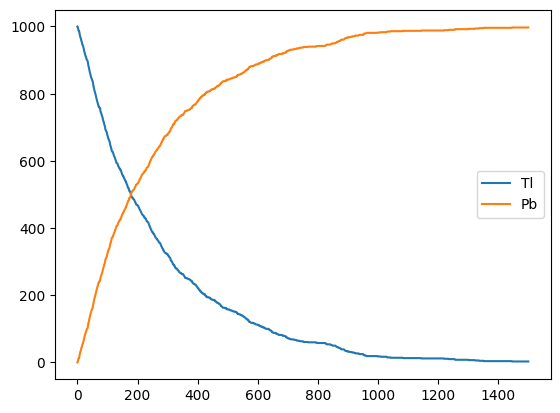

In [8]:
plt.plot(np.linspace(0,T_max,1500),Tl_hist, label = 'Tl')
plt.plot(np.linspace(0,T_max,1500),Pb_hist, label = 'Pb')
plt.legend()

In [17]:
# Inverse transform method:
N = 1000 #number of random draws

#pdf: 
#pdf_t = np.log(2)/tau * 2**(-t/tau)
#cdf: integral de pdf de 0 a t
#cdf_t = 1 - 2**(-t/tau)
#inverse cdf -> U = F(t) e depois isola t
T_inverse_cdf = (-tau/np.log(2))*(np.log(1 - np.random.random(N))) #draws from uniform distribution

Tl_alive = []

for t in times:
    alive = np.sum(T_inverse_cdf > t) #mostra quantos ainda estao vivos em cada segundo do tempo
    Tl_alive.append(alive)

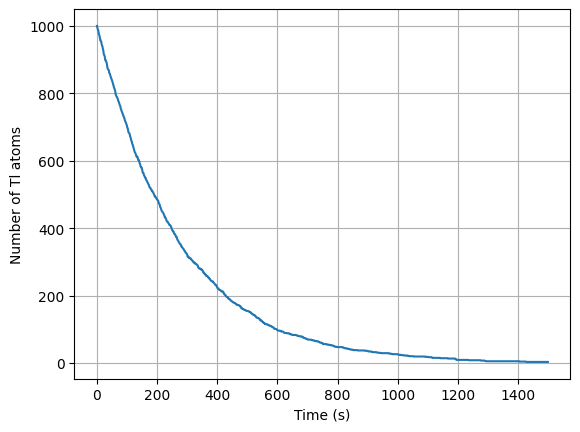

In [18]:
plt.plot(times, Tl_alive)
plt.xlabel("Time (s)")
plt.ylabel("Number of Tl atoms")
plt.grid()

### Summarize:

**primeira parte:** 
* cria as variaveis
* cria as listas de tl e pb
* cria a 'linha de tempo - arange'
* for i in times:
* soma de np.random.random(atomos de tl) < prob
* sub em tl; add em pb
* plota

**segunda parte:**
* tem a pdf: integra pra cdf
* u = F(T) -> isola T
* obtem a funcao q transforma a uniforme em tempo
* lista de t historico alive
* for t in times:
* se o tempo_morreu(inverse cdf) > t -> vivo
* append of ta vivo
* plota ao longo do tempo